## Your task  2


In [1]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph

In [67]:
import math


class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    result: str


def process_value(state: AgentState):
    # result = None
    # if state['operation'] == '+':
    #     result = sum(state['values'])
    # elif state['operation'] == '*':
    #     result = 1
    #     for value in state['values']:
    #         result = result * value

    # state['result'] = "Hi " + state['name'] + " , your answer is: {result}"
    if state["operation"] == "+":
        state["result"] = f"Hi {state['name']}, your answer is: {sum(state['values'])}"
    elif state["operation"] == "*":
        state["result"] = f"Hi {state['name']}, your answer is: {math.prod(state['values'])}"
    else:
        state["result"] = "Invalid!"
    return state

In [68]:
graph = StateGraph(AgentState)

graph.add_node('processer', process_value)

graph.set_entry_point('processer')
graph.set_finish_point('processer')

app = graph.compile()

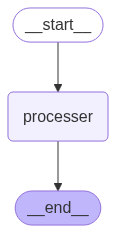

In [69]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [70]:
answers = app.invoke({"name": "Jack Sparrow","values": [1,2,3,4] , "operation": "*"})

In [71]:
print(answers["result"])

Hi Jack Sparrow, your answer is: 24
